In [1]:
#setup-imports-and-paths
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from IPython.display import display, Math
import sympy as sp

#project-root-path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

#figures-folder-path
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Figures folder:", FIGURES_DIR)
print("Notebook setup complete.")

Project root: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project
Figures folder: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\figures
Notebook setup complete.


In [2]:
#gamma0-decay rate into free space-parameter
gamma0 = 1.0

#gammac-decay rate into cavity-parameter
alpha = 5.0
gammac = alpha * gamma0

#gamma-total decay rate-parameter
gamma_total = gamma0 + gammac

#time-grid-dimensionless-time-gamma0t
tau_min = 0.0
tau_max = 2.0
num_points = 500
tau_grid = np.linspace(tau_min, tau_max, num_points)

#physical-time-grid-t=tau/gamma0
t_grid = tau_grid / gamma0

print("gamma0 =", gamma0)
print("gammac =", gammac)
print("gamma_total =", gamma_total)
print("Using dimensionless time tau = gamma0 * t")

gamma0 = 1.0
gammac = 5.0
gamma_total = 6.0
Using dimensionless time tau = gamma0 * t


In [3]:
#latex-analytical-result
Gamma0, Gammac, t, tau = sp.symbols(r"\Gamma_0 \Gamma_c t \tau", positive=True)

rho_ee_t = sp.exp(-(Gamma0 + Gammac) * t)
rho_ee_tau = sp.exp(-(1 + alpha) * tau)

display(Math(r"\langle \sigma_{ee}(t) \rangle = " + sp.latex(rho_ee_t)))
display(Math(r"\Gamma_c = 5\Gamma_0 \quad \Rightarrow \quad \langle \sigma_{ee}(\tau) \rangle = " + sp.latex(rho_ee_tau)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [4]:
#basis-states-calc
ket_e = np.array([[1.0], 
                  [0.0]], dtype=complex)

ket_g = np.array([[0.0], 
                  [1.0]], dtype=complex)

#sigma_minus-atomic-lowering-operator-calc
sigma_minus = ket_g @ ket_e.conj().T

#sigma_plus-atomic-raising-operator-calc
sigma_plus = sigma_minus.conj().T

#sigma_ee-excited-state-population-operator-calc
sigma_ee = sigma_plus @ sigma_minus

#identity-single-atom-operator-calc
identity_2 = np.eye(2, dtype=complex)

print("ket_e =\n", ket_e)
print("ket_g =\n", ket_g)
print("sigma_minus =\n", sigma_minus)
print("sigma_plus =\n", sigma_plus)
print("sigma_ee =\n", sigma_ee)

ket_e =
 [[1.+0.j]
 [0.+0.j]]
ket_g =
 [[0.+0.j]
 [1.+0.j]]
sigma_minus =
 [[0.+0.j 0.+0.j]
 [1.+0.j 0.+0.j]]
sigma_plus =
 [[0.-0.j 1.-0.j]
 [0.-0.j 0.-0.j]]
sigma_ee =
 [[1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]


In [5]:
#rho0-density-matrix-initial-state-calc
rho0 = ket_e @ ket_e.conj().T

#rho0-vectorised-for-ode-solver-calc
rho0_vec = rho0.reshape(-1)

print("rho0 =\n", rho0)
print("trace(rho0) =", np.trace(rho0))
print("rho0 vectorised =", rho0_vec)

rho0 =
 [[1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]
trace(rho0) = (1+0j)
rho0 vectorised = [1.+0.j 0.+0.j 0.+0.j 0.+0.j]


In [7]:
#master-equation-rhs-function
def master_equation_rhs(t, rho_vec, gamma_total, sigma_minus, sigma_plus):
    """
    #rho-density matrix-calc
    Computes d rho / dt for the single-atom Lindblad master equation.

    #gamma-total-decay-rate-parameter
    gamma_total = gamma0 + gammac

    #sigma_minus-atomic-lowering-operator-calc
    #sigma_plus-atomic-raising-operator-calc
    """
    
    #rho-vector-to-matrix-calc
    rho = rho_vec.reshape((2, 2))
    
    #projector-excited-state-calc
    sigma_plus_sigma_minus = sigma_plus @ sigma_minus
    
    #jump-term-calc
    jump_term = 2 * sigma_minus @ rho @ sigma_plus
    
    #loss-term-left-calc
    loss_left = sigma_plus_sigma_minus @ rho
    
    #loss-term-right-calc
    loss_right = rho @ sigma_plus_sigma_minus
    
    #lindblad-rhs-calc
    drho_dt = (gamma_total / 2.0) * (jump_term - loss_left - loss_right)
    
    #return-vectorised-rhs-calc
    return drho_dt.reshape(-1)

In [8]:
#solve-master-equation-numerically
solution = solve_ivp(
    fun=lambda t, y: master_equation_rhs(
        t, y, gamma_total, sigma_minus, sigma_plus
    ),
    t_span=(t_grid[0], t_grid[-1]),
    y0=rho0_vec,
    t_eval=t_grid,
    method="RK45",
    rtol=1e-9,
    atol=1e-11,
)

print("Solver success:", solution.success)
print("Solver message:", solution.message)
print("Number of time points:", len(solution.t))

Solver success: True
Solver message: The solver successfully reached the end of the integration interval.
Number of time points: 500


In [9]:
#extract-excited-state-population-calc
rho_t_list = solution.y.T.reshape((-1, 2, 2))

#population-excited-state-from-density-matrix-calc
pop_excited_numerical = np.array([
    np.real(np.trace(sigma_ee @ rho_t)) for rho_t in rho_t_list
])

#population-excited-state-analytical-calc
pop_excited_analytical = np.exp(-gamma_total * t_grid)

#population-error-calc
max_abs_error = np.max(np.abs(pop_excited_numerical - pop_excited_analytical))

print("Initial numerical population:", pop_excited_numerical[0])
print("Final numerical population:", pop_excited_numerical[-1])
print("Maximum absolute error:", max_abs_error)

Initial numerical population: 1.0
Final numerical population: 6.144215965820127e-06
Maximum absolute error: 1.1829959234432863e-10


In [10]:
#density-matrix-sanity-checks
trace_values = np.array([np.trace(rho_t) for rho_t in rho_t_list])
hermiticity_errors = np.array([
    np.max(np.abs(rho_t - rho_t.conj().T)) for rho_t in rho_t_list
])

print("Trace at first time:", trace_values[0])
print("Trace at final time:", trace_values[-1])
print("Maximum trace deviation:", np.max(np.abs(trace_values - 1.0)))
print("Maximum Hermiticity error:", np.max(hermiticity_errors))

Trace at first time: (1+0j)
Trace at final time: (0.9999999999999999+0j)
Maximum trace deviation: 5.551115123125783e-16
Maximum Hermiticity error: 0.0


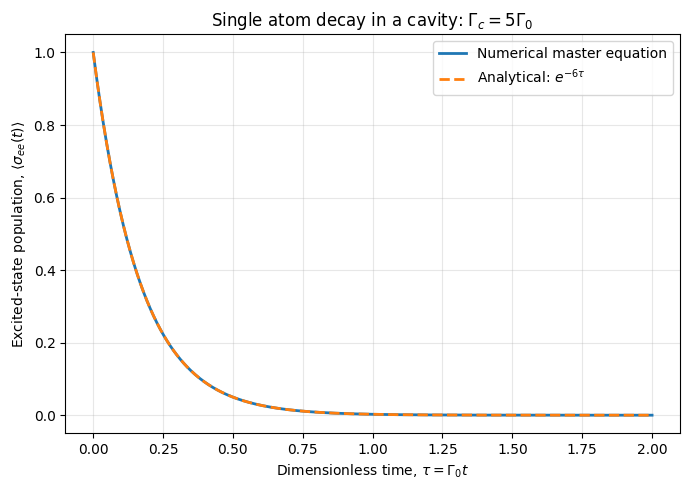

Saved figure to: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\figures\single_atom_master_equation_vs_analytical.png


In [14]:
#plot-single-atom-master-equation-vs-analytical
plt.figure(figsize=(7, 5))

plt.plot(
    tau_grid,
    pop_excited_numerical,
    label="Numerical master equation",
    linewidth=2,
)

plt.plot(
    tau_grid,
    pop_excited_analytical,
    "--",
    label=r"Analytical: $e^{-6\tau}$",
    linewidth=2,
)

plt.xlabel(r"Dimensionless time, $\tau = \Gamma_0 t$")
plt.ylabel(r"Excited-state population, $\langle \sigma_{ee}(t) \rangle$")
plt.title(r"Single atom decay in a cavity: $\Gamma_c = 5\Gamma_0$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

figure_path = FIGURES_DIR / "single_atom_master_equation_vs_analytical.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)

In [12]:
#table-selected-values-for-report
import pandas as pd

selected_indices = np.linspace(0, len(tau_grid) - 1, 8, dtype=int)

results_table = pd.DataFrame({
    "Gamma0_t": tau_grid[selected_indices],
    "Numerical_population": pop_excited_numerical[selected_indices],
    "Analytical_population": pop_excited_analytical[selected_indices],
    "Absolute_error": np.abs(
        pop_excited_numerical[selected_indices] 
        - pop_excited_analytical[selected_indices]
    ),
})

results_table

,Gamma0_t,Numerical_population,Analytical_population,Absolute_error
0,0.000000,1.000000,1.000000,0.000000e+00
1,0.284569,0.181334,0.181334,6.863499e-11
2,0.569138,0.032882,0.032882,2.358302e-11
3,0.853707,0.005963,0.005963,1.186705e-11
4,1.142285,0.001056,0.001056,4.974186e-12
5,1.426854,0.000191,0.000191,2.646916e-12
6,1.711423,0.000035,0.000035,5.021886e-13
7,2.000000,0.000006,0.000006,3.612492e-12


In [13]:
#report-note-single-atom-master-equation
print(
    "For a single initially excited atom in a cavity with no Hamiltonian term, "
    "the Lindblad master equation predicts exponential decay of the excited-state population. "
    "With Gamma_c = 5 Gamma_0, the total decay rate is Gamma_c + Gamma_0 = 6 Gamma_0. "
    "The numerical master-equation solution agrees with the analytical result "
    "exp(-6 Gamma_0 t), validating the numerical implementation."
)

For a single initially excited atom in a cavity with no Hamiltonian term, the Lindblad master equation predicts exponential decay of the excited-state population. With Gamma_c = 5 Gamma_0, the total decay rate is Gamma_c + Gamma_0 = 6 Gamma_0. The numerical master-equation solution agrees with the analytical result exp(-6 Gamma_0 t), validating the numerical implementation.
